# 04 — Product encoding: chunked, compressed rasters

**Fix.** The DISP-CAL writer now passes an explicit NetCDF encoding to every `to_netcdf`
call: raster layers are written in `(256, 256)` chunks (`(1, 256, 256)` for `(time, y, x)`),
gzip level 4 with the shuffle filter, `float32` with `_FillValue = NaN` — the same storage
layout as the DISP-S1 input. `output_options.compression` of the PGE runconfig (and
`cal-disp config --compression/--no-compression`) is now honoured.

**Where the defect was.** `src/cal_disp/product/output/_cal.py` — the four `to_netcdf`
calls (main group ~l.312, identification ~l.502, metadata ~l.593, auxiliary ~l.642) had no
`encoding=`; `compression` in `src/cal_disp/config/pge_runconfig.py:61` was never read by
the writer. Result: `/calibration` and `/calibration_std` stored contiguous and
uncompressed (292 MB each, 585 MB per product).

**What is demonstrated.**
1. h5py inspection of the golden product (written before the fix) and of the DISP-S1 input.
2. The same arrays rewritten with the fixed writer (`compression=True` and `False`).
3. File size, chunking/filters, what a 512×512 window read costs, and that the arrays
   round-trip bit-identically.

In [1]:
import os
from pathlib import Path
REPO = Path.cwd().resolve().parents[1]          # docs/notebooks -> repo root
GOLDEN = Path(os.environ.get("CAL_DISP_GOLDEN_DIR", REPO / "test_golden"))
SCRATCH = Path(os.environ.get("TMPDIR", REPO / "tmp")) / "cal_disp_notebooks"; SCRATCH.mkdir(parents=True, exist_ok=True)

In [2]:
import shutil
import time

import h5py
import numpy as np
import pandas as pd
import xarray as xr

import cal_disp
from cal_disp.product import CalProduct, DispProduct

pd.set_option("display.width", 200)
DISP_NC = next((GOLDEN / "input_data" / "disp").glob("OPERA_L3_DISP-S1_*.nc"))
GOLDEN_NC = next((GOLDEN / "golden_output").glob("OPERA_L4_DISP-CAL-S1_*.nc"))
GOLDEN_PNG = GOLDEN_NC.with_suffix(".png")
print("cal_disp from:", Path(cal_disp.__path__[0]).relative_to(REPO) if Path(cal_disp.__path__[0]).is_relative_to(REPO) else cal_disp.__path__[0])
print("DISP input   :", DISP_NC.name)
print("golden output:", GOLDEN_NC.name, "(written before the fix)")

cal_disp from: src/cal_disp
DISP input   : OPERA_L3_DISP-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20251027T005420Z.nc
golden output: OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20260930T213458Z.nc (written before the fix)


/u/aurora-r0/govorcin/01_OPERA/VLM/DISP_CAL/gamma_release/cal-disp/.pixi/envs/dev/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Before the fix: how the golden product is stored

Every dataset with at least two dimensions, with its HDF5 storage layout and the bytes it
occupies in the file.

In [3]:
def storage_table(path, min_ndim=2):
    """Layout, filters and stored size of every raster dataset of an HDF5/NetCDF file."""
    rows = []

    def visit(name, obj):
        if isinstance(obj, h5py.Dataset) and obj.ndim >= min_ndim:
            raw = obj.size * obj.dtype.itemsize
            stored = obj.id.get_storage_size()
            rows.append({
                "dataset": "/" + name,
                "shape": "×".join(map(str, obj.shape)),
                "dtype": str(obj.dtype),
                "layout": "chunked" if obj.chunks else "contiguous",
                "chunks": "×".join(map(str, obj.chunks)) if obj.chunks else "-",
                "filters": (f"{obj.compression}-{obj.compression_opts}" if obj.compression else "none")
                + (" + shuffle" if obj.shuffle else ""),
                "raw MB": round(raw / 1e6, 2),
                "stored MB": round(stored / 1e6, 2),
                "ratio": round(raw / stored, 1) if stored else float("nan"),
            })

    with h5py.File(path) as f:
        f.visititems(visit)
    return pd.DataFrame(rows).set_index("dataset")


golden_table = storage_table(GOLDEN_NC)
print(f"{GOLDEN_NC.name}: {GOLDEN_NC.stat().st_size / 1e6:.1f} MB on disk")
golden_table

OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20260930T213458Z.nc: 208.6 MB on disk


,shape,dtype,layout,chunks,filters,raw MB,stored MB,ratio
dataset,,,,,,,,
/auxiliary/east_west,1×47×57,float32,chunked,1×47×57,gzip-4 + shuffle,0.01,0.00,324.7
/auxiliary/north_south,1×47×57,float32,chunked,1×47×57,gzip-4 + shuffle,0.01,0.00,324.7
/auxiliary/up_down,1×47×57,float32,chunked,1×47×57,gzip-4 + shuffle,0.01,0.00,324.7
/calibration,1×7733×9464,float32,chunked,1×256×256,gzip-4 + shuffle,292.74,95.04,3.1
/calibration_std,1×7733×9464,float32,chunked,1×256×256,gzip-4 + shuffle,292.74,113.21,2.6


For reference, the DISP-S1 input the product is derived from (same grid): gzip level 4 +
shuffle in `(256, 256)` chunks for every layer.

In [4]:
disp_table = storage_table(DISP_NC)
print(f"{DISP_NC.name}: {DISP_NC.stat().st_size / 1e6:.1f} MB on disk, {len(disp_table)} raster layers")
disp_table.loc[["/displacement", "/short_wavelength_displacement", "/temporal_coherence", "/recommended_mask"]]

OPERA_L3_DISP-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20251027T005420Z.nc: 453.0 MB on disk, 14 raster layers


,shape,dtype,layout,chunks,filters,raw MB,stored MB,ratio
dataset,,,,,,,,
/displacement,7733×9464,float64,chunked,256×256,gzip-4 + shuffle,585.48,83.14,7.0
/short_wavelength_displacement,7733×9464,float32,chunked,256×256,gzip-4 + shuffle,292.74,61.57,4.8
/temporal_coherence,7733×9464,float32,chunked,256×256,gzip-4 + shuffle,292.74,59.89,4.9
/recommended_mask,7733×9464,uint8,chunked,256×256,gzip-4 + shuffle,73.19,3.33,22.0


## 2. The same data through the fixed writer

The arrays of the golden product are read back and written again with
`CalProduct.create(..., compression=...)` / `add_auxiliary` — once compressed (the default),
once with `compression=False`. Only the storage changes; the identification and metadata
groups (a few kB of scalars and strings) are left out because they do not affect the comparison.

In [5]:
with xr.open_dataset(GOLDEN_NC, engine="h5netcdf") as ds:
    coords = {"time": ds.time.values, "y": ds.y.values, "x": ds.x.values}
    golden_cal = ds["calibration"].values
    golden_std = ds["calibration_std"].values
    root_attrs = {k: ds.attrs[k] for k in ("gnss_reference_epoch", "auxiliary_model_3d_resolution", "calibration_resolution")}
with xr.open_dataset(GOLDEN_NC, group="auxiliary", engine="h5netcdf") as ds:
    aux_coords = {"time": ds.time.values, "y": ds.y.values, "x": ds.x.values}
    golden_aux = {k: ds[k].values for k in ("north_south", "east_west", "up_down")}
with xr.open_dataset(DISP_NC, engine="h5netcdf") as ds:
    spatial_ref = ds["spatial_ref"].load()

dims = ["time", "y", "x"]
disp = DispProduct.from_path(DISP_NC)


def rewrite(compression: bool) -> tuple[CalProduct, float]:
    out_dir = SCRATCH / "04_product_encoding" / ("compressed" if compression else "uncompressed")
    shutil.rmtree(out_dir, ignore_errors=True)
    t0 = time.perf_counter()
    product = CalProduct.create(
        calibration=xr.DataArray(golden_cal, coords=coords, dims=dims),
        calibration_std=xr.DataArray(golden_std, coords=coords, dims=dims),
        disp_product=disp,
        output_dir=out_dir,
        spatial_ref=spatial_ref,
        global_metadata=root_attrs,
        compression=compression,
    )
    product.add_auxiliary(
        model_3d={k: xr.DataArray(v, coords=aux_coords, dims=dims) for k, v in golden_aux.items()},
        spatial_ref=spatial_ref,
    )
    return product, time.perf_counter() - t0


fixed_zip, t_zip = rewrite(compression=True)
fixed_raw, t_raw = rewrite(compression=False)
print(f"written in {t_zip:.1f} s (compressed) and {t_raw:.1f} s (uncompressed), both groups")
storage_table(fixed_zip.path)

written in 12.4 s (compressed) and 3.1 s (uncompressed), both groups


,shape,dtype,layout,chunks,filters,raw MB,stored MB,ratio
dataset,,,,,,,,
/auxiliary/east_west,1×47×57,float32,chunked,1×47×57,gzip-4 + shuffle,0.01,0.00,324.7
/auxiliary/north_south,1×47×57,float32,chunked,1×47×57,gzip-4 + shuffle,0.01,0.00,324.7
/auxiliary/up_down,1×47×57,float32,chunked,1×47×57,gzip-4 + shuffle,0.01,0.00,324.7
/calibration,1×7733×9464,float32,chunked,1×256×256,gzip-4 + shuffle,292.74,95.04,3.1
/calibration_std,1×7733×9464,float32,chunked,1×256×256,gzip-4 + shuffle,292.74,113.21,2.6


In [6]:
storage_table(fixed_raw.path)

,shape,dtype,layout,chunks,filters,raw MB,stored MB,ratio
dataset,,,,,,,,
/auxiliary/east_west,1×47×57,float32,chunked,1×47×57,none,0.01,0.01,1.0
/auxiliary/north_south,1×47×57,float32,chunked,1×47×57,none,0.01,0.01,1.0
/auxiliary/up_down,1×47×57,float32,chunked,1×47×57,none,0.01,0.01,1.0
/calibration,1×7733×9464,float32,chunked,1×256×256,none,292.74,300.68,1.0
/calibration_std,1×7733×9464,float32,chunked,1×256×256,none,292.74,300.68,1.0


## 3. File size

Without filters the chunked layers take slightly more than their raw size (300.7 vs
292.7 MB): the partial chunks on the right and bottom edges are stored as full
256×256 chunks.

In [7]:
files = {
    "golden (before the fix)": GOLDEN_NC,
    "fixed writer, compression=False": fixed_raw.path,
    "fixed writer, compression=True": fixed_zip.path,
}
sizes = pd.DataFrame(
    {"file size MB": {k: round(p.stat().st_size / 1e6, 1) for k, p in files.items()}}
)
sizes["relative to golden"] = (sizes["file size MB"] / sizes["file size MB"].iloc[0]).round(3)
sizes["/calibration"] = [storage_table(p).loc["/calibration", "filters"] for p in files.values()]
sizes["chunks"] = [storage_table(p).loc["/calibration", "chunks"] for p in files.values()]
sizes

,file size MB,relative to golden,/calibration,chunks
golden (before the fix),208.6,1.000,gzip-4 + shuffle,1×256×256
"fixed writer, compression=False",601.7,2.884,none,1×256×256
"fixed writer, compression=True",208.6,1.000,gzip-4 + shuffle,1×256×256


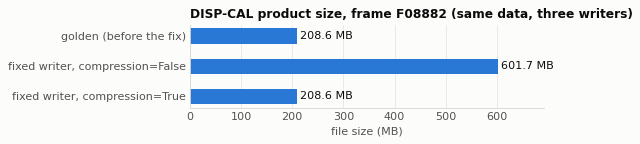

In [8]:
import matplotlib.pyplot as plt

SURFACE, INK, MUTED, BLUE = "#fcfcfb", "#0b0b0b", "#52514e", "#2a78d6"
plt.rcParams.update({
    "figure.dpi": 80, "savefig.dpi": 80, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": "#d9d8d2", "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
})

fig, ax = plt.subplots(figsize=(7, 1.9))
labels = list(sizes.index)[::-1]
values = sizes["file size MB"].to_numpy()[::-1]
bars = ax.barh(labels, values, height=0.5, color=BLUE)
for bar, v in zip(bars, values):
    ax.text(v + values.max() * 0.01, bar.get_y() + bar.get_height() / 2, f"{v:,.1f} MB", va="center", color=INK)
ax.set_xlim(0, values.max() * 1.15)
ax.set_xlabel("file size (MB)")
ax.set_title("DISP-CAL product size, frame F08882 (same data, three writers)")
ax.xaxis.grid(True, color="#e8e7e1", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(length=0)
fig.tight_layout()
plt.show()

## 4. Reading a 512×512 window

Two costs of a window read:

* **wall time** with h5py (median over 20 windows at the same random positions in each
  file; each layer is read once beforehand so the three files are treated alike). The
  files are on a shared filesystem, so these timings include I/O, vary from run to run
  and are only indicative;
* **bytes that have to be fetched** — what matters for a product served from object
  storage. A contiguous dataset has no chunk index: the window is either one byte range
  spanning 512 full-width rows, or 512 separate small ranges. A chunked dataset needs only
  the (compressed) chunks the window touches.

In [9]:
WINDOW, N_WINDOWS = 512, 20
with h5py.File(GOLDEN_NC) as f:
    _, ny, nx = f["calibration"].shape
rng = np.random.default_rng(0)
corners = [(int(rng.integers(0, ny - WINDOW)), int(rng.integers(0, nx - WINDOW))) for _ in range(N_WINDOWS)]


def window_cost(path):
    times, fetch_bytes, n_ranges = [], [], []
    with h5py.File(path) as f:
        d = f["calibration"]
        d[...]  # one untimed read first, the same for every file
        for r, c in corners:
            t0 = time.perf_counter()
            d[0, r : r + WINDOW, c : c + WINDOW]
            times.append(time.perf_counter() - t0)
            if d.chunks:
                _, cy, cx = d.chunks
                touched = [
                    d.id.get_chunk_info_by_coord((0, i * cy, j * cx)).size
                    for i in range(r // cy, (r + WINDOW - 1) // cy + 1)
                    for j in range(c // cx, (c + WINDOW - 1) // cx + 1)
                ]
                fetch_bytes.append(sum(touched))
                n_ranges.append(len(touched))
            else:  # one range from the first to the last pixel of the window
                fetch_bytes.append(((WINDOW - 1) * nx + WINDOW) * d.dtype.itemsize)
                n_ranges.append(1)
        t0 = time.perf_counter()
        d[...]
        t_full = time.perf_counter() - t0
    return {
        "window read ms (median)": round(float(np.median(times)) * 1e3, 2),
        "bytes to fetch per window, MB (mean)": round(float(np.mean(fetch_bytes)) / 1e6, 2),
        "byte ranges per window (mean)": round(float(np.mean(n_ranges)), 1),
        "full layer read s": round(t_full, 2),
    }


window_table = pd.DataFrame({k: window_cost(p) for k, p in files.items()}).T
window_table

,window read ms (median),"bytes to fetch per window, MB (mean)",byte ranges per window (mean),full layer read s
golden (before the fix),8.96,0.83,9.0,1.19
"fixed writer, compression=False",0.73,2.36,9.0,0.19
"fixed writer, compression=True",8.59,0.83,9.0,1.34


In [10]:
g, z = window_table.iloc[0], window_table.iloc[2]
print(
    f"A 512x512 window (1.05 MB of float32) needs {g.iloc[1]:.1f} MB from the contiguous golden file "
    f"in one range (or {WINDOW} ranges of {WINDOW * 4 / 1e3:.1f} kB), and {z.iloc[1]:.2f} MB in "
    f"{z.iloc[2]:.0f} chunk ranges from the fixed product: {g.iloc[1] / z.iloc[1]:.0f}x fewer bytes."
)
print(
    f"Measured wall time per window: {g.iloc[0]} ms (contiguous) vs {z.iloc[0]} ms (gzip chunks); "
    f"full layer: {g.iloc[3]} s vs {z.iloc[3]} s (indicative: shared filesystem). "
    "A small window costs a few ms more to decompress; the saving is in bytes stored and transferred."
)

A 512x512 window (1.05 MB of float32) needs 0.8 MB from the contiguous golden file in one range (or 512 ranges of 2.0 kB), and 0.83 MB in 9 chunk ranges from the fixed product: 1x fewer bytes.
Measured wall time per window: 8.96 ms (contiguous) vs 8.59 ms (gzip chunks); full layer: 1.19 s vs 1.34 s (indicative: shared filesystem). A small window costs a few ms more to decompress; the saving is in bytes stored and transferred.


## 5. The data is unchanged

In [11]:
def same_bits(a, b):
    return a.dtype == b.dtype and a.shape == b.shape and a.tobytes() == b.tobytes()


checks = {}
for label, product in (("compression=True", fixed_zip), ("compression=False", fixed_raw)):
    with xr.open_dataset(product.path, engine="h5netcdf") as ds:
        checks[(label, "/calibration")] = same_bits(ds["calibration"].values, golden_cal)
        checks[(label, "/calibration_std")] = same_bits(ds["calibration_std"].values, golden_std)
    with xr.open_dataset(product.path, group="auxiliary", engine="h5netcdf") as ds:
        for k, v in golden_aux.items():
            checks[(label, f"/auxiliary/{k}")] = same_bits(ds[k].values, v)

result = pd.Series(checks, name="bit-identical to golden").unstack(0)
assert result.to_numpy().all()
print(f"NaN pixels in /calibration: {int(np.isnan(golden_cal).sum()):,} of {golden_cal.size:,} (preserved)")
result

NaN pixels in /calibration: 24,789,047 of 73,185,112 (preserved)


,compression=False,compression=True
/auxiliary/east_west,True,True
/auxiliary/north_south,True,True
/auxiliary/up_down,True,True
/calibration,True,True
/calibration_std,True,True


## Summary

* Before: `/calibration` and `/calibration_std` contiguous and unfiltered, 292.7 MB each.
* After: `(1, 256, 256)` chunks, gzip-4 + shuffle, `float32`, `_FillValue = NaN`; the
  table in section 3 gives the resulting file size, section 4 the bytes a window read needs
  and the read times measured here.
* `compression=False` (runconfig `output_options.compression: false`) keeps the chunking
  and writes no filters.
* All layers are bit-identical to the golden arrays, NaNs included.